# Raw FITS Files

In [38]:
import numpy as np
import matplotlib
from matplotlib import rc
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import scipy
import scipy.io as sio
import csv
from scipy.io import readsav
from scipy.ndimage import shift
from scipy.ndimage import gaussian_filter
from scipy import interpolate
import pandas as pd
from bokeh.io import push_notebook, show, output_notebook
from bokeh.plotting import figure, show
from bokeh.models import ColumnDataSource, Label, LabelSet,BoxAnnotation, Range1d
from astropy.io import fits
output_notebook()

NORMALIZATION_INDEX = 800

Loading BokehJS ...

# Headers

In [2]:
image_file = '/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8064.red.fits' #path to your fits file

# Open the fits file, get the info we need, then close it to save on space
with fits.open(image_file) as hdu_list:
    object_info= hdu_list.info() #display the extensions of the fits file
    primary_header = hdu_list[0].header #store primary header
    extracted_header= hdu_list[1].header #store extracted header
    sky_header= hdu_list[2].header #store sky header
    scan_noise_header= hdu_list[3].header #store noise header

    primary=hdu_list[0]
    
    wavenumber = hdu_list[1].data.field(0) #get wavenumber data which is the first column of the EXTRACTED data table
    wavenumber.tolist() #make it into a list

    image_data=hdu_list[0].data #read in main extention, which contains 3d image cube
    
    sky= hdu_list[1].data.field(3) #get sky data (column labeled ATMO)
    
    hdu_list.close() #closes the fits file

#add doppler shift
wavenumber_ds=[]
for number in wavenumber:
    wavenumber_ds.append(number-0.0364) #Plus the Doppler Shift
#print(wavenumber_ds)

Filename: /Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/june_30_encrenaz_fits_files/TX22A0630.8064.red.fits
No.    Name      Ver    Type      Cards   Dimensions   Format
  0  PRIMARY       1 PrimaryHDU     137   (1792, 32, 47)   float32   
  1  EXTRACTED     1 TableHDU        31   1792R x 5C   [F12.4, E12.4, E12.4, E12.4, F12.6]   
  2  SKY           1 ImageHDU        11   (1792, 32)   float32   
  3  SCAN-NOISE    1 ImageHDU        11   (1792, 32)   float32   


In [3]:
print(primary_header)

SIMPLE  =                    T                                                  BITPIX  =                  -32                                                  NAXIS   =                    3                                                  NAXIS1  =                 1792                                                  NAXIS2  =                   32                                                  NAXIS3  =                   47                                                  EXTEND  =                    T                                                  COMMENT   The primary data unit contains a spectral-spatial-spatial             COMMENT    data cube                                                            COMMENT   The primary HDU is followed by a table extension                      COMMENT   (EXTNAME = EXTRACTED)                                                 COMMENT   giving the observed vacuum wavenumbers,                               COMMENT   flux through the slit, estimat

In [4]:
print(extracted_header)

XTENSION= 'TABLE   '                                                            BITPIX  =                    8                                                  NAXIS   =                    2                                                  NAXIS1  =                   80                                                  NAXIS2  =                 1792                                                  PCOUNT  =                    0                                                  GCOUNT  =                    1                                                  TFIELDS =                    5                                                  EXTNAME = 'EXTRACTED'                                                           TTYPE1  = 'WAVENUMBER'  / observed vacuum wavenumber                            TBCOL1  =                    1                                                  TFORM1  = 'F12.4'                                                               TUNIT1  = 'cm^-1   '                    

In [5]:
print(sky_header)

XTENSION= 'IMAGE   '                                                            BITPIX  =                  -32                                                  NAXIS   =                    2                                                  NAXIS1  =                 1792                                                  NAXIS2  =                   32                                                  PCOUNT  =                    0                                                  GCOUNT  =                    1                                                  CTYPE1  = 'spectral pixel'                                                      EXTNAME = 'SKY'  / sky frame which was subtracted from scan frames              BUNIT   = 'erg / s cm2 cm-1 sr'                                                 CTYPE2  = 'pixel along slit'                                                    END                                                                                                                     

In [6]:
print(scan_noise_header)

XTENSION= 'IMAGE   '                                                            BITPIX  =                  -32                                                  NAXIS   =                    2                                                  NAXIS1  =                 1792                                                  NAXIS2  =                   32                                                  PCOUNT  =                    0                                                  GCOUNT  =                    1                                                  CTYPE1  = 'spectral pixel'                                                      EXTNAME = 'SCAN-NOISE'  / calculated noise in each scan frame                   BUNIT   = 'erg / s cm2 cm-1 sr'                                                 CTYPE2  = 'pixel along slit'                                                    END                                                                                                                     

# Data Load-In

## Line-by-Line

In [7]:
#import line by line (assuming gathered from HITRAN)
df=pd.read_fwf('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/line_by_line/H2O_line_by_line.txt',header=None) 
wn=df.loc[:,0]
abund=df.loc[:,1]
split_df=pd.concat([wn,abund],axis=1)
split_array=split_df.to_numpy()
#print(split_array)

#get desired wavenumbers

mol_lambda1=[]
abund_lambda1=[]
for a in range(0,len(split_array),1):
    if split_array[a,0] > 1342 and split_array[a,0] < 1348:
        if split_array[a,1] > 4e-25: # and split_array[a,1] < 1e-22: #remove the and for the regular limit
            mol_lambda1.append(split_array[a,0]) #get list of wavenumber locations
            abund_lambda1.append(split_array[a,1]) # get corresponding strengths

print(len(mol_lambda1))
range_array=np.stack((mol_lambda1, abund_lambda1),axis=-1) #make locations and strengths one array
line_locations_encrenaz = np.array(mol_lambda1) #make it match previous naming structure

#to plot on normalized data on non-interactive plot:
#for place in range(0,len(line_locations_encrenaz)):
    #ax.plot([range_array[place,0],range_array[place,0]], [1,0.60],color='black')

#to plot on normalized data on interactive plot:
#for place in range(0,len(line_locations_encrenaz)):
    #q.line([range_array[place,0],range_array[place,0]], [1,0.60],color='black',line_width=1,name=str(range_array[place,1]))

9


## Cross-Section

In [8]:
cross_section_wavenumber = []
cross_section_spectrum = []


with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/encrenaz_test/cross_sections/Cross Section TXT Files - SO2_cross_section.csv') as cross_section_file:  
    plots = csv.reader(cross_section_file, delimiter = ',') 
      
    for row in plots: 
        cross_section_wavenumber.append(float(row[0]))
        cross_section_spectrum.append(float(row[1]))
        
#to plot on normalized data on non-interactive plot:
#ax.plot(cross_section_wavenumber,cross_section_spectrum, label = 'Cross-Section', color='black')

#to plot on normalized data on interactive plot:
#q.line(cross_section_wavenumber, cross_section_spectrum,legend_label='Cross-Section', color='black')

# Geographical Information

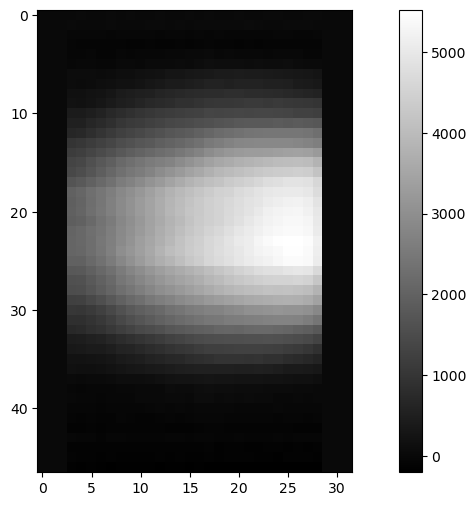

In [9]:
total_image = np.sum(image_data,axis=2) #summed up all wavenumbers to collapse into 2d image

#total_image[12:21,7:26]=0 #this was me testing which region I wanted to sum over for the spectrum collapse afterwards

fig, ax = plt.subplots(figsize=(12, 6))

plt.imshow(total_image, cmap='gray')

plt.colorbar()

# FITS Spectra

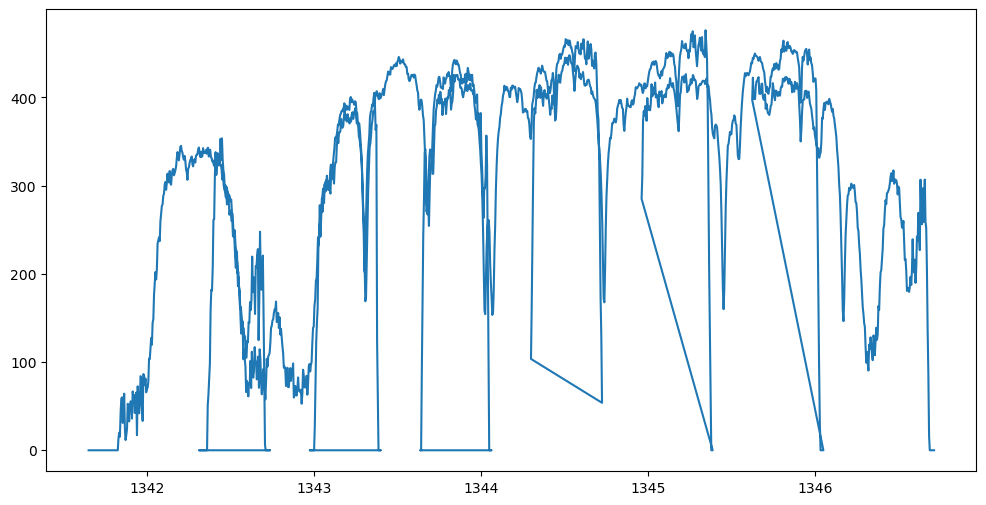

In [10]:
spectrum = np.sum(np.sum(image_data[12:21,7:26,0:1792],axis=0),axis=0)

fig, ax = plt.subplots(figsize=(12, 6))

ax.plot(wavenumber,spectrum)

plt.show()

In [11]:
sky_bump=sky*1100

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits Files",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

#q.line(wavenumber, spectrum, legend_label='venus', color='green')
#q.line(wavenumber_ds, spectrum, legend_label='venus shifted', color='red')
#q.line(wavenumber, sky_bump,legend_label='sky', color='blue')
#q.line(wavenumber, divided,legend_label='sky', color='red')

#divided = spectrum/sky_bump

q.legend.location = "bottom_right"

show(q)

/Users/physicsstudent2/anaconda3/lib/python3.10/site-packages/bokeh/models/plots.py:815: UserWarning: 
You are attempting to set `plot.legend.location` on a plot that has zero legends added, this will have no effect.

Before legend properties can be set, you must add a Legend explicitly, or call a glyph method with a legend parameter set.

  warnings.warn(_LEGEND_EMPTY_WARNING % attr)


# PSG Spectra

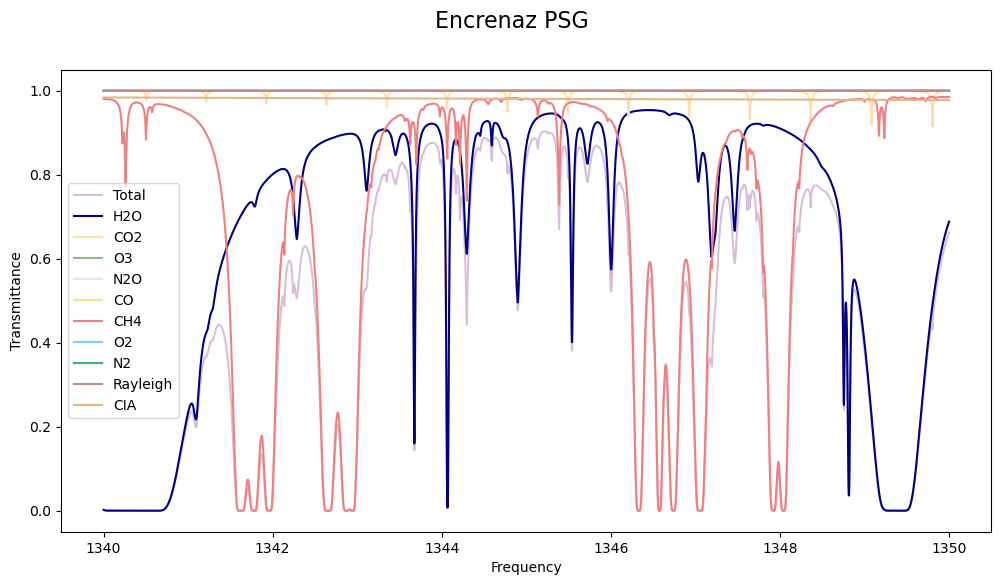

In [12]:
encrenaz_wavenumber = []
encrenaz_total_spectrum = []
encrenaz_H2O_spectrum = []
encrenaz_CO2_spectrum = []
encrenaz_O3_spectrum = []
encrenaz_N2O_spectrum = []
encrenaz_CO_spectrum = []
encrenaz_CH4_spectrum = []
encrenaz_O2_spectrum = []
encrenaz_N2_spectrum = []
encrenaz_SO2_spectrum = []
encrenaz_Rayleigh_spectrum = []
encrenaz_CIA_spectrum = []


with open('/Users/physicsstudent2/desktop/venus_research/BSRI_2024/PSG/PSG TXT Files - encrenaz.csv') as encrenaz_psg_file:  
    plots = csv.reader(encrenaz_psg_file, delimiter = ',') 
      
    for row in plots: 
        encrenaz_wavenumber.append(float(row[0]))
        encrenaz_total_spectrum.append(float(row[1]))
        encrenaz_H2O_spectrum.append(float(row[2]))
        encrenaz_CO2_spectrum.append(float(row[3]))
        encrenaz_O3_spectrum.append(float(row[4]))
        encrenaz_N2O_spectrum.append(float(row[5]))
        encrenaz_CO_spectrum.append(float(row[6]))
        encrenaz_CH4_spectrum.append(float(row[7]))
        encrenaz_O2_spectrum.append(float(row[8]))
        encrenaz_N2_spectrum.append(float(row[9]))
        encrenaz_Rayleigh_spectrum.append(float(row[10]))
        encrenaz_CIA_spectrum.append(float(row[11]))
        
fig, ax = plt.subplots(figsize=(12, 6))
plt.xlabel('Frequency')
plt.ylabel('Transmittance')
fig.suptitle('Encrenaz PSG', fontsize=16)


ax.plot(encrenaz_wavenumber,encrenaz_total_spectrum, label = 'Total', color='thistle')
ax.plot(encrenaz_wavenumber,encrenaz_H2O_spectrum, label = 'H2O', color='navy')
ax.plot(encrenaz_wavenumber,encrenaz_CO2_spectrum, label = 'CO2', color='navajowhite')
ax.plot(encrenaz_wavenumber,encrenaz_O3_spectrum, label = 'O3', color='darkseagreen')
ax.plot(encrenaz_wavenumber,encrenaz_N2O_spectrum, label = 'N2O', color='lavender')
ax.plot(encrenaz_wavenumber,encrenaz_CO_spectrum, label = 'CO',  color='khaki')
ax.plot(encrenaz_wavenumber,encrenaz_CH4_spectrum, label = 'CH4', color='lightcoral')
ax.plot(encrenaz_wavenumber,encrenaz_O2_spectrum, label = 'O2', color='lightskyblue')
ax.plot(encrenaz_wavenumber,encrenaz_N2_spectrum, label = 'N2', color='mediumseagreen')
ax.plot(encrenaz_wavenumber,encrenaz_Rayleigh_spectrum, label = 'Rayleigh', color='rosybrown')
ax.plot(encrenaz_wavenumber,encrenaz_CIA_spectrum, label = 'CIA', color='burlywood')

plt.legend()

plt.show()        

In [13]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Encrenaz PSG",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(encrenaz_wavenumber, encrenaz_total_spectrum, legend_label='Total', color='thistle')
q.line(encrenaz_wavenumber, encrenaz_H2O_spectrum,legend_label='H2O', color='navy')
q.line(encrenaz_wavenumber, encrenaz_CO2_spectrum,legend_label='CO2', color='navajowhite')
q.line(encrenaz_wavenumber, encrenaz_O3_spectrum,legend_label='O3', color='darkseagreen')
q.line(encrenaz_wavenumber, encrenaz_N2O_spectrum,legend_label='N2O', color='lavender')
q.line(encrenaz_wavenumber, encrenaz_CO_spectrum,legend_label='CO', color='khaki')
q.line(encrenaz_wavenumber, encrenaz_CH4_spectrum,legend_label='CH4', color='lightcoral')
q.line(encrenaz_wavenumber, encrenaz_O2_spectrum,legend_label='O2', color='lightskyblue')
q.line(encrenaz_wavenumber, encrenaz_N2_spectrum,legend_label='N2', color='mediumseagreen')
q.line(encrenaz_wavenumber, encrenaz_SO2_spectrum,legend_label='N2', color='orchid')
q.line(encrenaz_wavenumber, encrenaz_Rayleigh_spectrum,legend_label='Rayleigh', color='rosybrown')
q.line(encrenaz_wavenumber, encrenaz_CIA_spectrum,legend_label='CIA', color='burlywood')

q.legend.location = "bottom_right"

show(q)

# Data Processing

## Separating Orders

In [14]:
order_array = np.zeros(len(wavenumber))
order_count = 1
for i in range(len(wavenumber)):
     if i == 0:
          order_array[i] = order_count
     else:
          if wavenumber[i] < wavenumber[i-1]:
               order_count = order_count+1
               order_array[i] = order_count
          else:
               order_array[i] = order_count

print(len(order_array))
print(order_array[0:256])

1792
[1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.
 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1. 1.]


### Order One

In [15]:
o1_wavenumber = wavenumber[0:256]
o1_spectrum = spectrum[0:256]
o1_min = o1_wavenumber[0]
#print(o1_min)
o1_max = o1_wavenumber[255]
#print(o1_max)
#print(o1_wavenumber)

encrenaz_reversed = list(reversed(encrenaz_wavenumber))
o1_index_min = (np.abs(encrenaz_reversed - o1_min)).argmin() - 2
#print(o1_index_min)
#print(encrenaz_reversed[o1_index_min])
o1_index_max = (np.abs(encrenaz_reversed - o1_max)).argmin() + 2
#print(o1_index_max)
#print(encrenaz_reversed[o1_index_max])
o1_encrenaz_wavenumber = encrenaz_reversed[o1_index_min:o1_index_max]
#print(o1_encrenaz_wavenumber)

H2O_reversed = list(reversed(encrenaz_H2O_spectrum))
CO2_reversed = list(reversed(encrenaz_CO2_spectrum))
CH4_reversed = list(reversed(encrenaz_CH4_spectrum))
o1_H2O = H2O_reversed[o1_index_min:o1_index_max]
o1_CO2 = CO2_reversed[o1_index_min:o1_index_max]
o1_CH4 = CH4_reversed[o1_index_min:o1_index_max]

o1_sky = sky[0:256]
o1_sky_bump = o1_sky / np.median(o1_sky)

In [16]:
exp_H2O = 0 #exponent on water transmission
exp_CO2 = 0 #exponent on CO2 transmission
exp_CH4 = 0 #exponent on CH4 transmission

o1_H2O_exp=[]
o1_CO2_exp=[]
o1_CH4_exp=[]
for number in o1_H2O:
    o1_H2O_exp.append(number**exp_H2O)
for number in o1_CO2:
    o1_CO2_exp.append(number**exp_CO2)
for number in o1_CH4:
    o1_CH4_exp.append(number**exp_CH4)

o1_total = np.array(o1_H2O_exp)*np.array(o1_CH4_exp)*np.array(o1_CO2_exp)

k = 2.5
#Gaussian sigma of resolution broadening, in pixels

wavenumber_shift = 0.3 #empirical wavenumber shift to improve residuals

o1_gaussian = gaussian_filter(o1_total,k)

o1_interpolate = scipy.interpolate.interp1d(o1_encrenaz_wavenumber, o1_gaussian)
o1_interpolate_function = o1_interpolate(o1_wavenumber)

o1_telluric = shift(o1_interpolate_function, wavenumber_shift)
normalized_o1_telluric = o1_telluric / np.median(o1_telluric)


o1_normalized_spectrum = o1_spectrum / np.median(o1_spectrum)
o1_processed_spectrum = np.divide(o1_normalized_spectrum,o1_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_16493/1203378137.py:32: RuntimeWarning: invalid value encountered in divide
  o1_processed_spectrum = np.divide(o1_normalized_spectrum,o1_telluric)


In [17]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order One",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(o1_wavenumber, normalized_o1_telluric, legend_label='order one corrected telluric', color='orange')
q.line(o1_wavenumber, o1_processed_spectrum, legend_label='order one venus processed', color='green')
q.line(o1_wavenumber, o1_normalized_spectrum, legend_label='order one venus unprocessed', color='red')
q.line(o1_wavenumber, o1_sky_bump,legend_label='order one sky', color='blue')

q.legend.location = "bottom_right"

show(q)

### Order Two

In [18]:
#print(order_array[256:512])
o2_wavenumber = wavenumber[256:512]
o2_spectrum = spectrum[256:512]
o2_min = o2_wavenumber[0]
#print(o2_min)
o2_max = o2_wavenumber[255]
#print(o2_max)

o2_index_min = (np.abs(encrenaz_reversed - o2_min)).argmin() - 2
print(o2_index_min)
#print(encrenaz_reversed[o2_index_min])
o2_index_max = (np.abs(encrenaz_reversed - o2_max)).argmin() + 2
print(o2_index_max)
#print(encrenaz_reversed[o2_index_max])
o2_encrenaz_wavenumber = encrenaz_reversed[o2_index_min:o2_index_max]

o2_H2O = H2O_reversed[o2_index_min:o2_index_max]
o2_CO2 = CO2_reversed[o2_index_min:o2_index_max]
o2_CH4 = CH4_reversed[o2_index_min:o2_index_max]

o2_sky = sky[256:512]
o2_sky_bump = o2_sky / np.median(o2_sky)

860
1268


In [19]:
exp_H2O = 0 #exponent on water transmission
exp_CO2 = 0 #exponent on CO2 transmission
exp_CH4 = 0 #exponent on CH4 transmission

o2_H2O_exp=[]
o2_CO2_exp=[]
o2_CH4_exp=[]
for number in o2_H2O:
    o2_H2O_exp.append(number**exp_H2O)
for number in o2_CO2:
    o2_CO2_exp.append(number**exp_CO2)
CH4_exp=[]
for number in o2_CH4:
    o2_CH4_exp.append(number**exp_CH4)

o2_total = np.array(o2_H2O_exp)*np.array(o2_CH4_exp)*np.array(o2_CO2_exp)

k = 2.5 #Gaussian sigma of resolution broadening, in pixels

wavenumber_shift = 0.3 #empirical wavenumber shift to improve residuals

o2_gaussian = gaussian_filter(o2_total,k)

o2_interpolate = scipy.interpolate.interp1d(o2_encrenaz_wavenumber, o2_gaussian)
o2_interpolate_function = o2_interpolate(o2_wavenumber)

o2_telluric = shift(o2_interpolate_function, wavenumber_shift)
normalized_o2_telluric = o2_telluric / np.median(o2_telluric)


o2_normalized_spectrum = o2_spectrum / np.median(o2_spectrum)
o2_processed_spectrum = np.divide(o2_normalized_spectrum,o2_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_16493/3620525936.py:32: RuntimeWarning: invalid value encountered in divide
  o2_processed_spectrum = np.divide(o2_normalized_spectrum,o2_telluric)


In [20]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Two",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(o2_wavenumber, normalized_o2_telluric, legend_label='order two corrected telluric', color='orange')
q.line(o2_wavenumber, o2_processed_spectrum, legend_label='order two venus processed', color='green')
q.line(o2_wavenumber, o2_normalized_spectrum, legend_label='order two venus unprocessed', color='red')
q.line(o2_wavenumber, o2_sky_bump,legend_label='order two sky', color='blue')

q.legend.location = "bottom_right"

show(q)

### Order Three

In [21]:
print(order_array[512:768])
o3_wavenumber = wavenumber[512:768]
o3_spectrum = spectrum[512:768]
o3_min = o3_wavenumber[0]
#print(o3_min)
o3_max = o3_wavenumber[255]
#print(o3_max)

o3_index_min = (np.abs(encrenaz_reversed - o3_min)).argmin() - 2
print(o3_index_min)
#print(encrenaz_reversed[o2_index_min])
o3_index_max = (np.abs(encrenaz_reversed - o3_max)).argmin() + 2
print(o3_index_max)
#print(encrenaz_reversed[o2_index_max])
o3_encrenaz_wavenumber = encrenaz_reversed[o3_index_min:o3_index_max]

o3_H2O = H2O_reversed[o3_index_min:o3_index_max]
o3_CO2 = CO2_reversed[o3_index_min:o3_index_max]
o3_CH4 = CH4_reversed[o3_index_min:o3_index_max]

o3_sky = sky[512:768]
o3_sky_bump = o3_sky / np.median(o3_sky)

[3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.
 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3. 3.]
1106
1515


In [22]:
exp_H2O = 0.3 #exponent on water transmission
exp_CO2 = 0.3 #exponent on CO2 transmission
exp_CH4 = 0.4 #exponent on CH4 transmission

o3_H2O_exp=[]
o3_CO2_exp=[]
o3_CH4_exp=[]
for number in o3_H2O:
    o3_H2O_exp.append(number**exp_H2O)
for number in o3_CO2:
    o3_CO2_exp.append(number**exp_CO2)
for number in o3_CH4:
    o3_CH4_exp.append(number**exp_CH4)

o3_total = np.array(o3_H2O_exp)*np.array(o3_CH4_exp)*np.array(o3_CO2_exp)

k = 2.5 #Gaussian sigma of resolution broadening, in pixels

wavenumber_shift = 0.3 #empirical wavenumber shift to improve residuals

o3_gaussian = gaussian_filter(o3_total,k)

o3_interpolate = scipy.interpolate.interp1d(o3_encrenaz_wavenumber, o3_gaussian)
o3_interpolate_function = o3_interpolate(o3_wavenumber)

o3_telluric = shift(o3_interpolate_function, wavenumber_shift)
normalized_o3_telluric = o3_telluric / np.median(o3_telluric)

o3_normalized_spectrum = o3_spectrum / np.median(o3_spectrum)
o3_processed_spectrum = np.divide(o3_normalized_spectrum,o3_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_16493/788759988.py:30: RuntimeWarning: invalid value encountered in divide
  o3_processed_spectrum = np.divide(o3_normalized_spectrum,o3_telluric)


In [23]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Three",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(o3_wavenumber, normalized_o3_telluric, legend_label='order three corrected telluric', color='orange')
q.line(o3_wavenumber, o3_processed_spectrum, legend_label='order three venus processed', color='green')
q.line(o3_wavenumber, o3_normalized_spectrum, legend_label='order three venus unprocessed', color='red')
q.line(o3_wavenumber, o3_sky_bump,legend_label='order three sky', color='blue')

q.legend.location = "bottom_right"

show(q)

### Order Four

In [24]:
#print(order_array[768:1024])
o4_wavenumber = wavenumber[768:1024]
o4_spectrum = spectrum[768:1024]
o4_min = o4_wavenumber[0]
#print(o4_min)
o4_max = o4_wavenumber[255]
#print(o4_max)

o4_index_min = (np.abs(encrenaz_reversed - o4_min)).argmin() -2
print(o4_index_min)
#print(encrenaz_reversed[o2_index_min])
o4_index_max = (np.abs(encrenaz_reversed - o4_max)).argmin() + 2
print(o4_index_max)
#print(encrenaz_reversed[o2_index_max])
o4_encrenaz_wavenumber = encrenaz_reversed[o4_index_min:o4_index_max]

o4_H2O = H2O_reversed[o4_index_min:o4_index_max]
o4_CO2 = CO2_reversed[o4_index_min:o4_index_max]
o4_CH4 = CH4_reversed[o4_index_min:o4_index_max]

o4_sky = sky[768:1024]
o4_sky_bump = o4_sky / np.median(o4_sky)

1353
1761


In [25]:
exp_H2O = 0.35 #exponent on water transmission
exp_CO2 = 0.3 #exponent on CO2 transmission
exp_CH4 = 0.4 #exponent on CH4 transmission

o4_H2O_exp=[]
o4_CO2_exp=[]
o4_CH4_exp=[]
for number in o4_H2O:
    o4_H2O_exp.append(number**exp_H2O)
for number in o4_CO2:
    o4_CO2_exp.append(number**exp_CO2)
CH4_exp=[]
for number in o4_CH4:
    o4_CH4_exp.append(number**exp_CH4)

o4_total = np.array(o4_H2O_exp)*np.array(o4_CH4_exp)*np.array(o4_CO2_exp)

k = 2.5 #Gaussian sigma of resolution broadening, in pixels

wavenumber_shift = 0.3 #empirical wavenumber shift to improve residuals

o4_gaussian = gaussian_filter(o4_total,k)

o4_interpolate = scipy.interpolate.interp1d(o4_encrenaz_wavenumber, o4_gaussian)
o4_interpolate_function = o4_interpolate(o4_wavenumber)

o4_telluric = shift(o4_interpolate_function, wavenumber_shift)
normalized_o4_telluric = o4_telluric / np.median(o4_telluric)


o4_normalized_spectrum = o4_spectrum / np.median(o4_spectrum)
o4_processed_spectrum = np.divide(o4_normalized_spectrum,o4_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_16493/457691859.py:32: RuntimeWarning: invalid value encountered in divide
  o4_processed_spectrum = np.divide(o4_normalized_spectrum,o4_telluric)


In [26]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Four",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(o4_wavenumber, normalized_o4_telluric, legend_label='order four corrected telluric', color='orange')
q.line(o4_wavenumber, o4_processed_spectrum, legend_label='order four venus processed', color='green')
q.line(o4_wavenumber, o4_normalized_spectrum, legend_label='order four venus unprocessed', color='red')
q.line(o4_wavenumber, o4_sky_bump,legend_label='order four sky', color='blue')

q.legend.location = "bottom_right"

show(q)

### Order Five

In [27]:
#print(order_array[1024:1280])
o5_wavenumber = wavenumber[1024:1280]
o5_spectrum = spectrum[1024:1280]
o5_min = o5_wavenumber[0]
#print(o5_min)
o5_max = o5_wavenumber[255]
#print(o5_max)

o5_index_min = (np.abs(encrenaz_reversed - o5_min)).argmin() - 2
print(o5_index_min)
#print(encrenaz_reversed[o2_index_min])
o5_index_max = (np.abs(encrenaz_reversed - o5_max)).argmin() + 2
print(o5_index_max)
#print(encrenaz_reversed[o2_index_max])
o5_encrenaz_wavenumber = encrenaz_reversed[o5_index_min:o5_index_max]

o5_H2O = H2O_reversed[o5_index_min:o5_index_max]
o5_CO2 = CO2_reversed[o5_index_min:o5_index_max]
o5_CH4 = CH4_reversed[o5_index_min:o5_index_max]

o5_sky = sky[1024:1280]
o5_sky_bump = o5_sky / np.median(o5_sky)

1599
2007


In [28]:
exp_H2O = 0.35 #exponent on water transmission
exp_CO2 = 0.3 #exponent on CO2 transmission
exp_CH4 = 0.4 #exponent on CH4 transmission

o5_H2O_exp=[]
o5_CO2_exp=[]
o5_CH4_exp=[]
for number in o5_H2O:
    o5_H2O_exp.append(number**exp_H2O)
for number in o5_CO2:
    o5_CO2_exp.append(number**exp_CO2)
CH4_exp=[]
for number in o5_CH4:
    o5_CH4_exp.append(number**exp_CH4)

o5_total = np.array(o5_H2O_exp)*np.array(o5_CH4_exp)*np.array(o5_CO2_exp)

k = 2.5 #Gaussian sigma of resolution broadening, in pixels

wavenumber_shift = 0.3 #empirical wavenumber shift to improve residuals

o5_gaussian = gaussian_filter(o5_total,k)

o5_interpolate = scipy.interpolate.interp1d(o5_encrenaz_wavenumber, o5_gaussian)
o5_interpolate_function = o5_interpolate(o5_wavenumber)

o5_telluric = shift(o5_interpolate_function, wavenumber_shift)
normalized_o5_telluric = o5_telluric / np.median(o5_telluric)


o5_normalized_spectrum = o5_spectrum / np.median(o5_spectrum)
o5_processed_spectrum = np.divide(o5_normalized_spectrum,o5_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_16493/237220756.py:32: RuntimeWarning: divide by zero encountered in divide
  o5_processed_spectrum = np.divide(o5_normalized_spectrum,o5_telluric)


In [29]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Five",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(o5_wavenumber, normalized_o5_telluric, legend_label='order five corrected telluric', color='orange')
q.line(o5_wavenumber, o5_processed_spectrum, legend_label='order five venus processed', color='green')
q.line(o5_wavenumber, o5_normalized_spectrum, legend_label='order five venus unprocessed', color='red')
q.line(o5_wavenumber, o5_sky_bump,legend_label='order five sky', color='blue')

q.legend.location = "bottom_right"

show(q)

### Order Six

In [30]:
#print(order_array[1280:1536])
o6_wavenumber = wavenumber[1280:1536]
o6_spectrum = spectrum[1280:1536]
o6_min = o6_wavenumber[0]
#print(o5_min)
o6_max = o6_wavenumber[255]
#print(o5_max)

o6_index_min = (np.abs(encrenaz_reversed - o6_min)).argmin() - 2
print(o6_index_min)
#print(encrenaz_reversed[o6_index_min])
o6_index_max = (np.abs(encrenaz_reversed - o6_max)).argmin() + 2
print(o6_index_max)
#print(encrenaz_reversed[o6_index_max])
o6_encrenaz_wavenumber = encrenaz_reversed[o6_index_min:o6_index_max]

o6_H2O = H2O_reversed[o6_index_min:o6_index_max]
o6_CO2 = CO2_reversed[o6_index_min:o6_index_max]
o6_CH4 = CH4_reversed[o6_index_min:o6_index_max]

o6_sky = sky[1280:1536]
o6_sky_bump = o6_sky / np.median(o6_sky)

1845
2253


In [31]:
exp_H2O = 0.35 #exponent on water transmission
exp_CO2 = 0.3 #exponent on CO2 transmission
exp_CH4 = 0.4 #exponent on CH4 transmission

o6_H2O_exp=[]
o6_CO2_exp=[]
o6_CH4_exp=[]
for number in o6_H2O:
    o6_H2O_exp.append(number**exp_H2O)
for number in o6_CO2:
    o6_CO2_exp.append(number**exp_CO2)
for number in o6_CH4:
    o6_CH4_exp.append(number**exp_CH4)

o6_total = np.array(o6_H2O_exp)*np.array(o6_CH4_exp)*np.array(o6_CO2_exp)

k = 2.5 #Gaussian sigma of resolution broadening, in pixels

wavenumber_shift = 0.3 #empirical wavenumber shift to improve residuals

o6_gaussian = gaussian_filter(o6_total,k)

o6_interpolate = scipy.interpolate.interp1d(o6_encrenaz_wavenumber, o6_gaussian)
o6_interpolate_function = o6_interpolate(o6_wavenumber)

o6_telluric = shift(o6_interpolate_function, wavenumber_shift)
normalized_o6_telluric = o6_telluric / np.median(o6_telluric)


o6_normalized_spectrum = o6_spectrum / np.median(o6_spectrum)
o6_processed_spectrum = np.divide(o6_normalized_spectrum,o6_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_16493/781571226.py:31: RuntimeWarning: divide by zero encountered in divide
  o6_processed_spectrum = np.divide(o6_normalized_spectrum,o6_telluric)


In [32]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Six",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(o6_wavenumber, normalized_o6_telluric, legend_label='order six corrected telluric', color='orange')
q.line(o6_wavenumber, o6_processed_spectrum, legend_label='order six venus processed', color='green')
q.line(o6_wavenumber, o6_normalized_spectrum, legend_label='order six venus unprocessed', color='red')
q.line(o6_wavenumber, o6_sky_bump,legend_label='order six sky', color='blue')

q.legend.location = "bottom_right"

show(q)

### Order Seven

In [33]:
#print(order_array[1536:1792])
o7_wavenumber = wavenumber[1536:1792]
o7_spectrum = spectrum[1536:1792]
o7_min = o7_wavenumber[0]
#print(o7_min)
o7_max = o7_wavenumber[255]
#print(o7_max)

o7_index_min = (np.abs(encrenaz_reversed - o7_min)).argmin() - 2
print(o7_index_min)
#print(encrenaz_reversed[o7_index_min])
o7_index_max = (np.abs(encrenaz_reversed - o7_max)).argmin() + 2
print(o7_index_max)
#print(encrenaz_reversed[o7_index_max])
o7_encrenaz_wavenumber = encrenaz_reversed[o7_index_min:o7_index_max]

o7_H2O = H2O_reversed[o7_index_min:o7_index_max]
o7_CO2 = CO2_reversed[o7_index_min:o7_index_max]
o7_CH4 = CH4_reversed[o7_index_min:o7_index_max]

o7_sky = sky[1536:1792]
o7_sky_bump = o7_sky / np.median(o7_sky)

2091
2499


In [34]:
exp_H2O = 0.2 #exponent on water transmission
exp_CO2 = 0.2 #exponent on CO2 transmission
exp_CH4 = 0.2 #exponent on CH4 transmission

o7_H2O_exp=[]
o7_CO2_exp=[]
o7_CH4_exp=[]
for number in o7_H2O:
    o7_H2O_exp.append(number**exp_H2O)
for number in o7_CO2:
    o7_CO2_exp.append(number**exp_CO2)
for number in o7_CH4:
    o7_CH4_exp.append(number**exp_CH4)

o7_total = np.array(o7_H2O_exp)*np.array(o7_CH4_exp)*np.array(o7_CO2_exp)

k = 10 #Gaussian sigma of resolution broadening, in pixels

wavenumber_shift = 0.3 #empirical wavenumber shift to improve residuals

o7_gaussian = gaussian_filter(o7_total,k)

o7_interpolate = scipy.interpolate.interp1d(o7_encrenaz_wavenumber, o7_gaussian)
o7_interpolate_function = o7_interpolate(o7_wavenumber)

o7_telluric = shift(o7_interpolate_function, wavenumber_shift)
normalized_o7_telluric = o7_telluric / np.median(o7_telluric)


o7_normalized_spectrum = o7_spectrum / np.median(o7_spectrum)
o7_processed_spectrum = np.divide(o7_normalized_spectrum,o7_telluric)

/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_16493/4160178116.py:31: RuntimeWarning: divide by zero encountered in divide
  o7_processed_spectrum = np.divide(o7_normalized_spectrum,o7_telluric)


In [35]:
TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Order Seven",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(o7_wavenumber, normalized_o7_telluric, legend_label='order seven corrected telluric', color='orange')
q.line(o7_wavenumber, o7_processed_spectrum, legend_label='order seven venus processed', color='green')
q.line(o7_wavenumber, o7_normalized_spectrum, legend_label='order seven venus unprocessed', color='red')
q.line(o7_wavenumber, o7_sky_bump,legend_label='order seven sky', color='blue')

q.legend.location = "bottom_right"

show(q)

## Whole Spectrum

In [36]:
exp_H2O = 0.2 #exponent on water transmission
exp_CO2 = 0.3 #exponent on CO2 transmission
exp_CH4 = 0.1 #exponent on CH4 transmission

H2O_exp=[]
for number in H2O_reversed:
    H2O_exp.append(number**exp_H2O)
CO2_exp=[]
for number in CO2_reversed:
    CO2_exp.append(number**exp_CO2)
CH4_exp=[]
for number in CH4_reversed:
    CH4_exp.append(number**exp_CH4)

total_multiplied = np.array(H2O_exp)*np.array(CH4_exp)*np.array(CO2_exp)

print(total_multiplied)

k = 10 #Gaussian sigma of resolution broadening, in pixels

wavenumber_shift = 0.3 #empirical wavenumber shift to improve residuals

gaussian = gaussian_filter(total_multiplied,k)

interpolate = scipy.interpolate.interp1d(encrenaz_reversed, gaussian)
interpolate_function = interpolate(wavenumber)

telluric = shift(interpolate_function, wavenumber_shift)
print(telluric)
normalized_telluric = telluric / np.median(telluric)

normalized_spectrum = spectrum / np.median(spectrum)
processed_spectrum = np.divide(normalized_spectrum,telluric)

normalized_processed = processed_spectrum / np.median(processed_spectrum)

#for x in range(len(normalized_spectrum)):
   #print(normalized_spectrum[x]),
#print(telluric)

#Curtis IDL telluric specturm:
#telluric = shift(interpolate.interp1d(gaussian_filter(total_multiplied,k),encrenaz_wavenumber,wavenumber),wavenumber_shift)

[0.29018308 0.28279281 0.2752106  ... 0.92561715 0.9260248  0.92642087]
[0.         0.41459915 0.45067038 ... 0.69187535 0.66739219 0.63634833]


/var/folders/0q/22yph8ws4w999mfg8_bqcg840000gn/T/ipykernel_16493/3120050605.py:33: RuntimeWarning: invalid value encountered in divide
  processed_spectrum = np.divide(normalized_spectrum,telluric)


In [40]:
sky_bump=sky / np.median(sky)

TOOLTIPS = [ ("x","$x{‘00.00000000’}"),("y","$y{‘00.000’}"), ("strength", "$name")]
q = figure(title="Fits Files",sizing_mode="stretch_width",
    height=500,tooltips=TOOLTIPS)

q.line(wavenumber +0.03, normalized_telluric, legend_label='corrected telluric', color='orange')
q.line(wavenumber+0.03, processed_spectrum, legend_label='venus processed', color='green')
q.line(wavenumber+0.03, normalized_spectrum, legend_label='venus unprocessed', color='red')
q.line(wavenumber+0.03, sky_bump,legend_label='sky', color='blue')

q.legend.location = "bottom_right"

q.x_range = Range1d(1345, 1345.3)

show(q)